# Project 14 - Production Serving & LLMOps (Docker + vLLM)

This is the project that turns your 10 years of data/ops experience into an AI paycheck. Anyone can
run a model in a notebook; few can **serve it** to thousands of users reliably and cheaply. We
simulate the key serving ideas here (batching throughput, latency SLOs, rate limiting) with runnable
code and diagrams, then give you the real **Docker + vLLM** stack.

**What you'll learn**
- Why **batching** is the secret to high-throughput LLM serving (you'll plot it).
- **Latency SLOs**: p50/p95/p99 and why averages lie.
- An **API gateway**'s job: auth, **rate limiting** (you'll build one), logging.
- The production stack: vLLM + FastAPI + Docker Compose + monitoring + CI/CD.

## The scenario
Your fine-tuned model works great for one request. Now 500 users hit it at once. Without the right
serving setup, latency explodes and your GPU bill balloons. Production serving (vLLM's batching),
a gateway (auth + rate limits), and monitoring (SLOs) are what keep it fast, safe, and affordable.

## Foundations (plain English)
- **Throughput vs latency:** throughput = requests/second served; latency = time for one request.
  Serving is about maximising throughput while keeping latency acceptable.
- **Continuous batching (vLLM):** a GPU has fixed overhead per step, so processing many requests
  *together* serves far more per second than one-at-a-time. This is the single biggest serving win.
- **SLO (Service Level Objective):** a target like "95% of requests under 800 ms". You watch the
  **p95/p99**, not the average, because a few slow requests ruin user experience.
- **API gateway:** the front door - checks API keys (**auth**), enforces **rate limits**, logs every
  request - before traffic reaches the model.
- **Containers (Docker):** package the model server + gateway + monitoring so they run identically
  anywhere - a data/ops instinct, applied to AI.

### Cell 1 - imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
rng = np.random.default_rng(0)
print("ready")

ready


### Cell 2 - why batching wins (throughput vs batch size)
A GPU step has a fixed overhead plus a small per-request cost. Processing a batch of B requests
together amortises the overhead, so per-request time drops and throughput soars - then plateaus.
This is exactly what vLLM's continuous batching exploits.

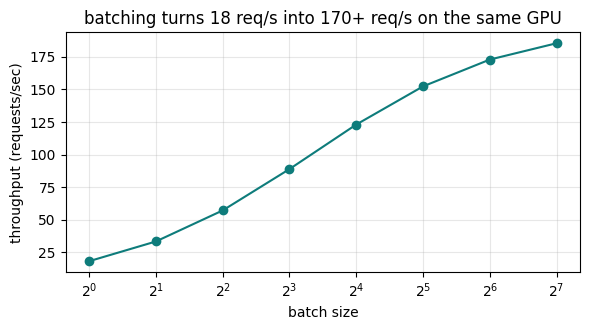

batch 1: 18 req/s   ->   batch 64: 173 req/s


In [2]:
overhead_ms, per_req_ms = 50.0, 5.0          # fixed GPU-step overhead vs marginal cost per request
B = np.array([1,2,4,8,16,32,64,128])
time_per_req = (overhead_ms + B*per_req_ms) / B     # ms per request when batched
throughput = 1000.0 / time_per_req                  # requests per second
plt.figure(figsize=(6,3.4))
plt.plot(B, throughput, "o-", color="#0e7c7b")
plt.xscale("log", base=2); plt.xlabel("batch size"); plt.ylabel("throughput (requests/sec)")
plt.title("batching turns 18 req/s into 170+ req/s on the same GPU"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"batch 1: {throughput[0]:.0f} req/s   ->   batch 64: {throughput[6]:.0f} req/s")

### Cell 3 - latency SLOs: watch the tail, not the average
We simulate 5000 request latencies. The average looks fine, but the **p95/p99** (the slow tail) is
what users feel. SLOs are set on the tail. The dashed line is our p95 target.

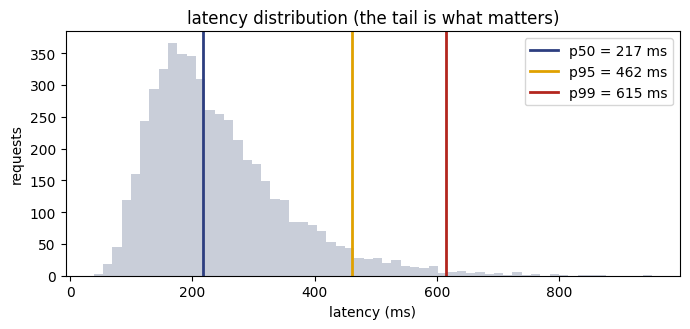

mean=243 ms looks fine, but p99=615 ms is the real user pain


In [3]:
lat = rng.lognormal(mean=np.log(220), sigma=0.45, size=5000)   # ms, realistically skewed
p50, p95, p99 = np.percentile(lat, [50, 95, 99])
plt.figure(figsize=(7,3.4))
plt.hist(lat, bins=60, color="#c9ced9")
for v,c,lab in [(p50,"#2d3e80","p50"),(p95,"#e0a100","p95"),(p99,"#b3261e","p99")]:
    plt.axvline(v, color=c, lw=2, label=f"{lab} = {v:.0f} ms")
plt.xlabel("latency (ms)"); plt.ylabel("requests"); plt.title("latency distribution (the tail is what matters)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"mean={lat.mean():.0f} ms looks fine, but p99={p99:.0f} ms is the real user pain")

### Cell 4 - build a rate limiter (token bucket) - a gateway's core job
A token bucket holds up to `capacity` tokens and refills at `refill`/sec. Each request spends one
token; if the bucket is empty, the request is rejected (HTTP 429). This protects your GPU from
bursts and abusive clients. We fire a burst of 20 requests and see which get through.

15/20 allowed, 5 rate-limited (429)


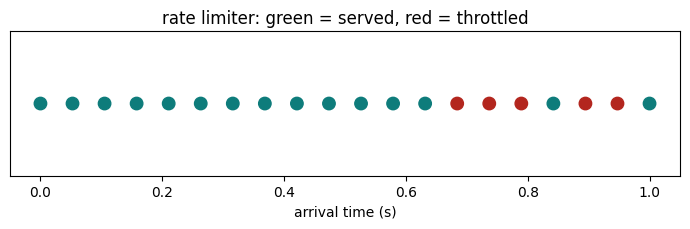

In [4]:
class TokenBucket:
    def __init__(self, capacity, refill_per_sec):
        self.capacity=capacity; self.refill=refill_per_sec; self.tokens=capacity; self.t=0.0
    def allow(self, now):
        self.tokens = min(self.capacity, self.tokens + (now-self.t)*self.refill); self.t=now
        if self.tokens >= 1: self.tokens -= 1; return True
        return False

bucket = TokenBucket(capacity=10, refill_per_sec=5)
arrivals = np.linspace(0, 1.0, 20)            # 20 requests within 1 second (a burst)
decisions = [bucket.allow(t) for t in arrivals]
allowed = sum(decisions)
print(f"{allowed}/20 allowed, {20-allowed} rate-limited (429)")
plt.figure(figsize=(7,2.4))
plt.scatter(arrivals, [1]*20, c=["#0e7c7b" if d else "#b3261e" for d in decisions], s=80)
plt.yticks([]); plt.xlabel("arrival time (s)"); plt.title("rate limiter: green = served, red = throttled")
plt.tight_layout(); plt.show()

### Cell 5 - diagram: the production serving architecture
Requests flow: client -> gateway (auth + rate limit + logging) -> vLLM model server (batched GPU
inference) -> response, with metrics streamed to monitoring. Each box is a container.

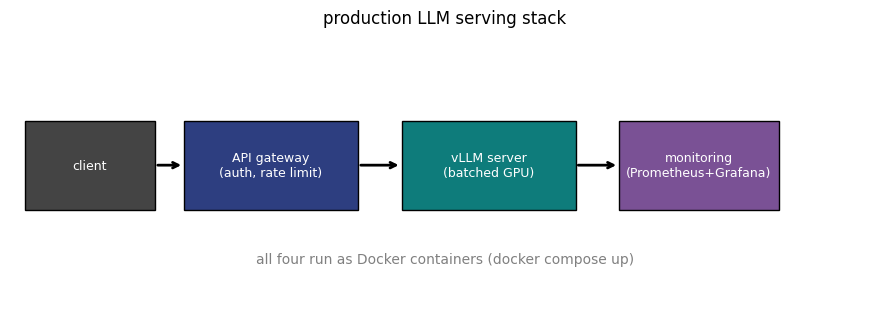

In [5]:
fig, ax = plt.subplots(figsize=(9,3.2)); ax.axis("off"); ax.set_xlim(0,12); ax.set_ylim(0,3)
def box(x,w,t,c): ax.add_patch(plt.Rectangle((x,1),w,1,facecolor=c,edgecolor="black")); ax.text(x+w/2,1.5,t,ha="center",va="center",color="white",fontsize=9)
box(0.2,1.8,"client",  "#444")
box(2.4,2.4,"API gateway\n(auth, rate limit)","#2d3e80")
box(5.4,2.4,"vLLM server\n(batched GPU)","#0e7c7b")
box(8.4,2.2,"monitoring\n(Prometheus+Grafana)","#7a5195")
for x0,x1 in [(2.0,2.4),(4.8,5.4),(7.8,8.4)]:
    ax.annotate("",(x1,1.5),(x0,1.5),arrowprops=dict(arrowstyle="->",lw=2))
ax.text(6,0.4,"all four run as Docker containers (docker compose up)",ha="center",color="grey")
ax.set_title("production LLM serving stack"); plt.tight_layout(); plt.show()

## The real thing - the Docker + vLLM stack
This is in your project folder (`14-llmops-deployment/`). One command brings up the whole system.

```yaml
# docker-compose.yml
services:
  vllm:                                   # high-throughput model server (continuous batching)
    image: vllm/vllm-openai:latest
    command: ["--model", "your-username/your-model"]
    ports: ["8000:8000"]
  gateway:                                # FastAPI: auth, rate limit, logging
    build: ./gateway
    ports: ["8080:8080"]
    depends_on: [vllm]
  prometheus: { image: prom/prometheus, ports: ["9090:9090"] }
  grafana:    { image: grafana/grafana,  ports: ["3000:3000"] }
```
```python
# gateway/app.py  (FastAPI in front of vLLM)
from fastapi import FastAPI, Header, HTTPException
app = FastAPI()
@app.get("/health")
def health(): return {"status": "ok"}
@app.post("/v1/chat/completions")
def chat(body: dict, authorization: str = Header(None)):
    if not valid_key(authorization): raise HTTPException(401)   # auth
    if not bucket.allow(time.time()):  raise HTTPException(429)  # rate limit
    return proxy_to_vllm(body)                                   # forward to the model server
```

**Make it production-grade:** load-test with Locust (record p50/p95 and max throughput), add a
Grafana dashboard, and a GitHub Actions pipeline that builds, tests, scans, and pushes the image.
Write a runbook (how to deploy and roll back). This repo is your strongest "I ship to production"
proof - exactly what 2026 employers screen for.

## What just happened (recap)
- **Batching** multiplies throughput on the same GPU (you plotted the curve) - vLLM's superpower.
- **SLOs** track the latency **tail** (p95/p99), not the average.
- An **API gateway** does auth + **rate limiting** (you built a token bucket) + logging.
- The production stack is vLLM + FastAPI + Docker Compose + monitoring + CI/CD - one `docker compose
  up` away, and the ops background is the edge here.

## Extensions
- **Tune batching:** change `overhead_ms`/`per_req_ms` - when does adding batch size stop helping?
- **Set an SLO:** pick a p95 target; how would you alert when it's breached?
- **Stricter limits:** lower the bucket capacity and watch more requests get throttled.
- **Project goal:** serve your fine-tuned model with vLLM behind a FastAPI gateway, containerize it,
  add monitoring + a load-test report, and write the runbook.

## Mini-glossary
**throughput/latency** req/sec vs time-per-request - **continuous batching** serve many requests per
GPU step - **p50/p95/p99** median and tail latencies - **SLO** a reliability target - **API gateway**
auth + rate limit + logging front door - **rate limiting / token bucket** cap request rate - **vLLM**
fast LLM server - **Docker Compose** run multi-container apps - **CI/CD** automated build/test/deploy.